# Five-year population, housing, and income estimates by state or county

The American Community Survey (ACS) is the Census Bureau's continuous
household survey. Its 5-year estimates pool five years of responses, which is
what lets them reach every county, however small. The detailed tables hold tens
of thousands of variables per vintage, each estimate with a margin of error.

This walkthrough pulls the 2019-2023 estimates for Oklahoma's 77 counties:
population, housing units, and median household income, each with its margin
of error. It then looks at the fifteen counties where tornadoes touched down on
the evening of 6 May 2024, the ones the
[disaster-declarations study](https://usdata.dev/studies/disaster-declarations/)
joins to FEMA's declarations. It needs `usdata[pandas]`, matplotlib, and a
Census key.

The Census Data API requires a key on every data request. Set
`USDATA_CENSUS_KEY` in the environment first; the
[ACS guide](https://docs.usdata.dev/providers/census-acs-5year/) says how to
get one. No key reaches the manifest, the lockfile, the cached file, or any
output below.

This product uses the Census Bureau Data API but is not endorsed or certified
by the Census Bureau.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; pandas {pd.__version__}")

Executed (UTC): 2026-09-27T20:56:03+00:00
usdata 0.30.0; pandas 3.0.6


## Select

The manifest names a vintage, the variables, and a place. `vintage: 2023` is
the five-year period 2019 through 2023; a date window is refused, because a
five-year estimate is not an instant. The variables are API names: `B01003`
is total population, `B25001` housing units, and `B19013` median household
income, each as an estimate (`_001E`) and its margin of error (`_001M`).
`location: Oklahoma` with `geography: county` asks for one row per county in
the state, in one request.

In [2]:
print(manifest.read_text())

name: oklahoma-counties-acs-2023
sources:
  - name: counties
    dataset: census:acs-5year
    location: Oklahoma
    variables: [NAME, B01003_001E, B01003_001M, B25001_001E, B25001_001M, B19013_001E, B19013_001M]
    params:
      vintage: 2023
      geography: county



## What arrives

One JSON file, as the service served it: a header row naming the columns, then
one row per county, every value a string. The response carries no copy of the
key and identical requests return identical bytes, so nothing is rewritten
before it is pinned. The vintage and the period it covers are not in the file,
so the asset records them as `properties`.

In [3]:
result = pull(manifest)
(item,) = result.fetched
print("File:", item.path.name)
print("Bytes:", item.provenance.size)
print("Checksum:", item.provenance.checksum)
print("Transformations:", item.provenance.transformations)
print("Credentials used:", item.provenance.credentials)
print("Properties:", item.asset.properties)

File: acs5_2023_40-counties_2a8ce0a8ecdf.json
Bytes: 6977
Checksum: sha256:5b0bd353b626ff745acaf5a66c8ba0d1a6142858bbc971ca424a560573ae1828
Transformations: []
Credentials used: ['USDATA_CENSUS_KEY']
Properties: {'vintage': '2023', 'period': '2019-2023'}


## Open

The reader returns one row per county with the columns as the API names them.
Estimates and margins of error are numbers; `NAME` and the geography codes stay
text, so `county` keeps its leading zeros.

In [4]:
acs = item.open()
print(f"{len(acs)} counties")
print(acs.dtypes.to_string())
acs.head()

77 counties
NAME           string
B01003_001E     Int64
B01003_001M     Int64
B25001_001E     Int64
B25001_001M     Int64
B19013_001E     Int64
B19013_001M     Int64
state          string
county         string


,NAME,B01003_001E,B01003_001M,B25001_001E,B25001_001M,B19013_001E,B19013_001M,state,county
0,"Adair County, Oklahoma",19595,-555555555,8123,37,48028,3543,40,001
1,"Alfalfa County, Oklahoma",5685,-555555555,2480,27,67870,6541,40,003
2,"Atoka County, Oklahoma",14255,-555555555,6015,38,52034,2895,40,005
3,"Beaver County, Oklahoma",5041,-555555555,2467,18,64266,5563,40,007
4,"Beckham County, Oklahoma",22202,-555555555,10120,67,52323,4425,40,009


Not every number is a measurement. The ACS writes a negative annotation code
where a value cannot be given, and the reader leaves those codes in place
because each means something different. Total population is controlled to the
Bureau's own population estimates, so it has no sampling error, and its margin
of error is `-555555555` in every county.

In [5]:
numbers = acs.select_dtypes("number")
codes = {
    column: sorted({int(v) for v in numbers.loc[numbers[column] < 0, column]}) for column in numbers
}
print("Negative codes by column:", {column: found for column, found in codes.items() if found})

Negative codes by column: {'B01003_001M': [-555555555]}


## A first look

A 5-year estimate reaches small counties, but it is less certain there. The
margin of error on median household income, as a share of the estimate,
against each county's population, with the counties that had a tornado that
evening marked.

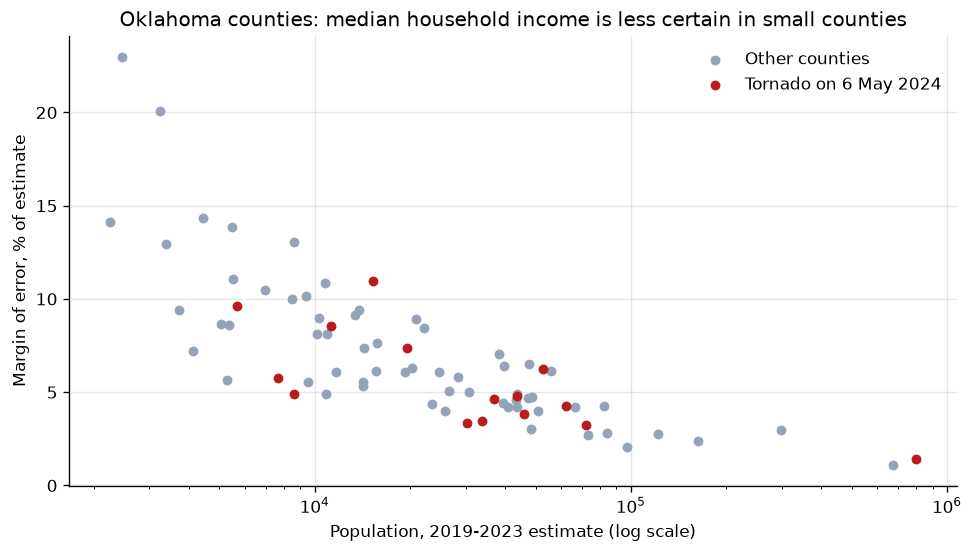

In [6]:
# The counties with tornado segments on 6 May 2024, as Storm Events writes their codes in the
# disaster-declarations study, padded to the three digits the ACS uses.
STORM_EVENTS_CODES = (1, 3, 11, 37, 47, 71, 73, 81, 93, 107, 109, 111, 113, 115, 147)
TORNADO = {f"{code:03}" for code in STORM_EVENTS_CODES}
income = acs[(acs.B19013_001E > 0) & (acs.B19013_001M > 0)].assign(
    relative_moe=lambda frame: 100 * frame.B19013_001M / frame.B19013_001E,
    tornado=lambda frame: frame.county.isin(TORNADO),
)
fig, ax = plt.subplots(layout="constrained")
for hit, group in income.groupby("tornado"):
    ax.scatter(
        group.B01003_001E,
        group.relative_moe,
        s=24,
        color="#b91c1c" if hit else "#94a3b8",
        label="Tornado on 6 May 2024" if hit else "Other counties",
        zorder=3 if hit else 2,
    )
ax.set_xscale("log")
ax.set_xlabel("Population, 2019-2023 estimate (log scale)")
ax.set_ylabel("Margin of error, % of estimate")
ax.set_title("Oklahoma counties: median household income is less certain in small counties")
ax.legend(frameon=False)
plt.show()

In [7]:
hit = acs[acs.county.isin(TORNADO)].sort_values("B01003_001E", ascending=False)
print(f"{len(hit)} counties with a tornado segment that evening")
print(f"Population: {hit.B01003_001E.sum():,}; housing units: {hit.B25001_001E.sum():,}")
hit[["NAME", "B01003_001E", "B25001_001E", "B25001_001M", "B19013_001E", "B19013_001M"]].rename(
    columns={
        "B01003_001E": "population",
        "B25001_001E": "housing units",
        "B25001_001M": "± housing",
        "B19013_001E": "median income ($)",
        "B19013_001M": "± income",
    }
)

15 counties with a tornado segment that evening
Population: 1,247,081; housing units: 555,665


,NAME,population,housing units,± housing,median income ($),± income
54,"Oklahoma County, Oklahoma",800487,356997,371,65374,926
18,"Creek County, Oklahoma",72353,31387,91,61849,2008
23,"Garfield County, Oklahoma",62322,27782,84,67302,2878
73,"Washington County, Oklahoma",52895,23745,41,61205,3814
56,"Osage County, Oklahoma",45963,19801,59,60482,2318
35,"Kay County, Oklahoma",43731,20923,111,56673,2707
55,"Okmulgee County, Oklahoma",36922,16708,44,53123,2469
40,"Lincoln County, Oklahoma",33917,14516,82,59425,2046
57,"Ottawa County, Oklahoma",30360,13695,138,48656,1641
0,"Adair County, Oklahoma",19595,8123,37,48028,3543


Housing units are counted closely: their margins are a few percent of the
estimate at most. Median income is less certain, and its margins run several
times wider in the smaller counties. Summing the populations is sound, since each is a
controlled count; a margin of error for a sum of estimates is not the sum of
their margins, and the Census Bureau documents how to approximate one.

## Pin and cite

`verify` checks the cached file against the lockfile's checksum without a
key. The response has no revision date, so a table the Bureau reissues shows up
as drift on a later pull, and `pull --update` accepts it deliberately.

In [8]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

census:acs-5year
  U.S. Census Bureau, American Community Survey 5-Year Estimates, Detailed Tables, Census Data API, accessed via usdata
  homepage: https://www.census.gov/data/developers/data-sets/acs-5year.html
  license: US Government Work (public domain)
  terms: https://www.census.gov/data/developers/about/terms-of-service.html
  retrieved: 2026-09-27; 1 checksummed asset (6,977 bytes) pinned by usdata 0.30.0
  sources: counties


## What was awkward

- The annotation codes arrive as ordinary numbers. `B01003_001M` is
  `-555555555` in every county, and a sum or mean over a margin column is
  nonsense until the codes are masked; nothing in the frame flags them.
- Finding a variable's name means reading the API's variable list for the
  vintage, outside usdata; `usdata info` lists only the handful in the catalog
  entry.
- Joining to Storm Events needs care with county codes: Storm Events writes
  `1` where the ACS writes `001`.
- The table does not say which five years it covers; the asset's `properties`
  do, and a copy of the file without its sidecar loses that.